In [1]:
# %%
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('..')

import pandas as pd
import numpy as np

from src.data_loader import DataLoader
from src.features import FeatureEngineer
from src.models import HybridForecaster
from src.validation import WalkForwardBacktester
from src.visualization import ModelVisualizer

In [2]:
# %%
loader = DataLoader(raw_data_path='../data/raw')
raw_data = loader.load_all_data()

sales_df = raw_data['sales']
promos_df = raw_data['promotions']

# %%
engineer = FeatureEngineer(
    sales_df=sales_df,
    promos_df=promos_df
)

master_df = engineer.run_pipeline()

print(master_df.head())
print(master_df.shape)

🚀 Loading raw data...


e:\DATATHON 2026\datathon-2026-round-1\notebook\..\src\data_loader.py:21: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, parse_dates=date_cols)


✅ Loaded 14 tables
⚙️ Running feature engineering...
✅ Feature shape: (3833, 24)
        date     revenue        cogs  t  t2  t3  dayofweek  month  day  \
0 2012-07-04  5123547.94  3982991.19  0   0   0          2      7    4   
1 2012-07-05  2751773.45  2150580.23  1   1   1          3      7    5   
2 2012-07-06  3054029.42  2517632.84  2   4   8          4      7    6   
3 2012-07-07  2667930.94  2108246.62  3   9  27          5      7    7   
4 2012-07-08  2360851.90  1808622.79  4  16  64          6      7    8   

   is_weekend  ...     cos_2     sin_3     cos_3     sin_4     cos_4  \
0           0  ...  0.992749 -0.179767 -0.983709  0.238673  0.971100   
1           0  ...  0.988023 -0.230306 -0.973118  0.304921  0.952378   
2           0  ...  0.982126 -0.280231 -0.959933  0.369725  0.929141   
3           1  ...  0.975065 -0.329408 -0.944188  0.432776  0.901502   
4           1  ...  0.966848 -0.377708 -0.925925  0.493776  0.869589   

      sin_5     cos_5  active_promos  max

In [3]:
# %%
print("NaN revenue:", master_df['revenue'].isna().sum())
print("Min revenue:", master_df['revenue'].min())
print("Max revenue:", master_df['revenue'].max())

neg = master_df[master_df['revenue'] < 0]
if not neg.empty:
    print("⚠️ Found negative revenue")
    display(neg.head())

NaN revenue: 0
Min revenue: 279813.94
Max revenue: 20905271.35


In [4]:
# 3. Khởi tạo Mô hình Hybrid (Option 1)
model = HybridForecaster()

In [5]:
# 4. Thiết lập các Fold cắt dữ liệu (Mô phỏng mù 1.5 năm như Kaggle test set)
# Tập sales.csv có dữ liệu từ 2012-07-04 đến 2022-12-31
# Ta sẽ lùi lại trong quá khứ để tạo 2 cửa sổ test dài 1.5 năm (18 tháng)
validation_splits = [
    {
        # Fold 1: Train đến hết 2019, Test 1.5 năm (đến giữa 2021)
        'train_end': '2019-12-31',
        'val_end': '2021-06-30'
    },
    {
        # Fold 2: Train đến giữa 2021, Test 1.5 năm (đến hết 2022)
        'train_end': '2021-06-30',
        'val_end': '2022-12-31'
    }
]

In [6]:
# 5. Khởi động Lò Bát Quái
backtester = WalkForwardBacktester(model=model, df=master_df)
results = backtester.run_backtest(validation_splits)


🚀 Running 2 folds backtest...

--- FOLD 1 ---
Train size: 2737
Val size  : 547
✅ Hybrid (Ridge + XGB) trained
MAE : 2253149.56
RMSE: 2638381.94
R2  : -1.2734

--- FOLD 2 ---
Train size: 3284
Val size  : 549


c:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=8.92798e-17): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


✅ Hybrid (Ridge + XGB) trained
MAE : 669440.77
RMSE: 869912.36
R2  : 0.6867

✅ Backtest completed


In [ ]:
# KHỞI ĐỘNG CỖ MÁY TRỰC QUAN HÓA
visualizer = ModelVisualizer()

# bảng metrics
visualizer.plot_metrics_table(results)

# plot tổng
visualizer.plot_backtest_results(results)

# từng fold
visualizer.plot_each_fold(results)

# residual
visualizer.plot_residuals(results)

# error theo time
visualizer.plot_error_over_time(results)

# scatter
visualizer.plot_scatter(results)

c:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


OBJECT COLS: Index([], dtype='object')


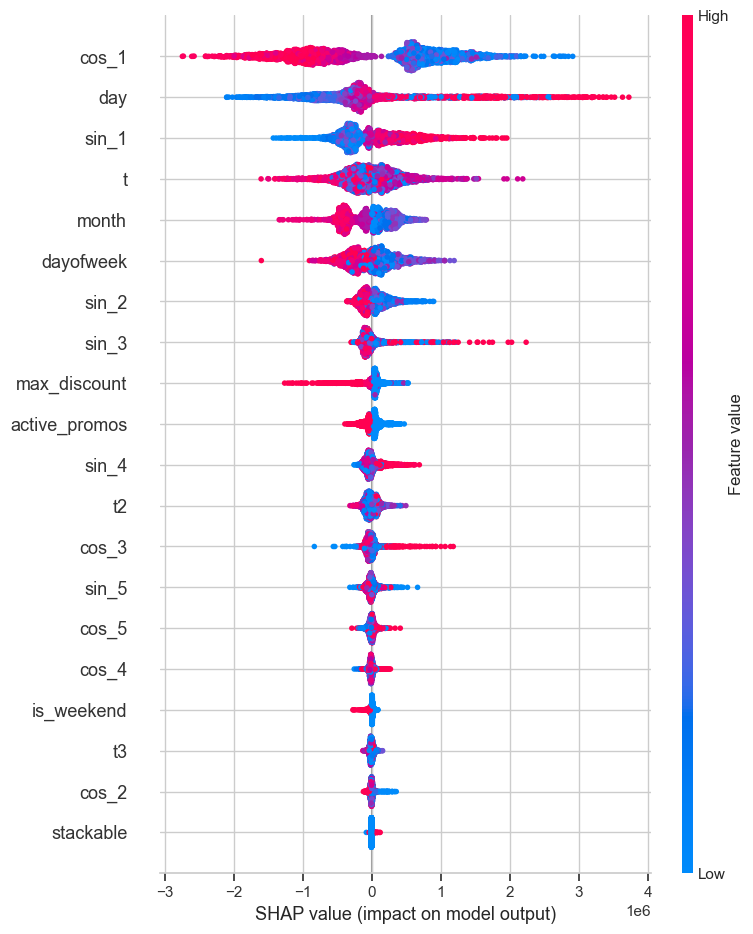

In [7]:
visualizer = ModelVisualizer()
# shap
train_df_final_fold = results[-1]['train_df']
visualizer.plot_shap_summary(model, train_df_final_fold)

In [ ]:
# ==========================================
# PHẦN 4: HUẤN LUYỆN TOÀN BỘ & XUẤT KAGGLE
# ==========================================
print("\n🚀 ĐANG HUẤN LUYỆN TRÊN TOÀN BỘ DỮ LIỆU ĐỂ NỘP KAGGLE...")

# Fit model trên 100% dữ liệu có sẵn (tới 31/12/2022)
model.fit(master_df)

# Lấy template file nộp
sample_sub = raw_data['sample_submission']

# Đảm bảo trục thời gian liên tục từ 01/01/2023 đến 01/07/2024
test_dates = pd.DataFrame({
    'date': pd.to_datetime(sample_sub['date'])
})

print(test_dates.head())

# --- BƯỚC QUAN TRỌNG: Tạo Features cho tập Test ---
# ❗ KHÔNG concat nữa vì model không dùng lag / rolling

test_engineer = FeatureEngineer(
    sales_df=test_dates,
    promos_df=raw_data['promotions']
)

master_test_df = test_engineer.run_pipeline()

# Lọc lại chỉ lấy khoảng thời gian Test
final_test_features = master_test_df[
    master_test_df['date'] >= '2023-01-01'
].copy()

# DỰ BÁO REVENUE
test_preds = model.predict(final_test_features)
sample_sub['revenue'] = np.round(test_preds, 2)

# ⚠️ PRO TIP CHO CỘT COGS (GIÁ VỐN)
# Tính tỷ lệ lịch sử rồi nhân ngược lại
historical_cogs_ratio = (
    master_df['cogs'].sum() / master_df['revenue'].sum()
)

sample_sub['cogs'] = np.round(sample_sub['revenue'] * historical_cogs_ratio, 2)


# Sửa lại tên cột nếu cần (ví dụ: 'date' -> 'Date', 'revenue' -> 'Revenue', 'cogs' -> 'COGS')
sample_sub.rename(columns={
    'date': 'Date',
    'revenue': 'Revenue',
    'cogs': 'COGS'
}, inplace=True)

# Lưu file Submission
sample_sub.to_csv('submission.csv', index=False)

print("✅ ĐÃ LƯU FILE submission.csv THÀNH CÔNG! SẴN SÀNG UPLOAD LÊN KAGGLE.")